# Dota 2: baseline для предсказания исхода матча

В этом ноутбуке я собираю базовый ML-пайплайн для соревнования по Dota 2: от первичного анализа данных до sparse-признаков по драфту героев и подбора логистической регрессии. Формат оставлен как исследовательский отчёт: что проверялось, зачем и какой вывод получился.


## 1. Метрика и загрузка данных

Сначала фиксирую метрику соревнования и смотрю на базовую структуру train/test. Важно сразу понять баланс таргета, временное разбиение и пропуски, потому что это влияет на выбор validation protocol.


In [1]:
from sklearn.metrics import roc_auc_score

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0


In [2]:
import pandas as pd

train_df = pd.read_csv("dota-2-hse-ml-1-course-competition-2026/matches_df_train.csv")
test_df = pd.read_csv("dota-2-hse-ml-1-course-competition-2026/matches_df_test.csv")


In [3]:
print("matches_df_train")
print(train_df.shape)
display(train_df.sample(10))
display(train_df.describe(include="all"))
display(train_df.isna().sum())

print("matches_df_test")
print(test_df.shape)
display(test_df.sample(10))
display(test_df.describe(include="all"))
display(test_df.isna().sum())


matches_df_train
(641090, 7)


,match_id,date,region,game_mode,duration,radiant_win,avg_mmr
581349,696261,2024-05-19,Europe West,1,2188,True,1595.7
379271,453952,2024-08-20,US West,1,3501,False,6524.5
548714,657277,2024-11-03,Europe West,2,1400,True,2147.8
362234,433642,2024-09-27,Europe West,22,2618,True,NaN
622932,746065,2024-05-18,Middle East,22,2236,False,2648.5
252473,302287,2024-09-05,SE Asia,1,1815,False,NaN
206457,247038,2024-10-06,Europe West,22,1689,True,NaN
283915,339896,2024-07-09,Europe West,3,1632,False,3138.2
518806,621401,2024-01-30,Europe West,22,2899,False,NaN
253148,303089,2024-09-30,South America,2,2144,True,NaN


,match_id,date,region,game_mode,duration,radiant_win,avg_mmr
count,641090.000000,641090,641090,641090.000000,641090.000000,641090,472334.000000
unique,NaN,335,10,NaN,NaN,2,NaN
top,NaN,2024-01-19,Europe West,NaN,NaN,True,NaN
freq,NaN,2110,402930,NaN,NaN,327451,NaN
mean,383791.138898,NaN,NaN,9.472508,2544.662008,NaN,3133.928477
std,221701.444546,NaN,NaN,9.954080,720.510457,NaN,1759.367566
min,1.000000,NaN,NaN,1.000000,0.000000,NaN,243.700000
25%,191835.250000,NaN,NaN,1.000000,2070.000000,NaN,1677.400000
50%,383788.500000,NaN,NaN,2.000000,2499.000000,NaN,2846.850000
75%,575786.750000,NaN,NaN,22.000000,2986.000000,NaN,4428.975000


match_id            0
date                0
region              0
game_mode           0
duration            0
radiant_win         0
avg_mmr        168756
dtype: int64

matches_df_test
(59748, 5)


,match_id,date,region,game_mode,avg_mmr
15934,205714,2024-12-11,US East,1,1398.9
12394,160658,2024-12-11,Europe West,22,NaN
48741,626644,2024-12-08,Europe West,1,1824.1
56340,724043,2024-12-22,Europe West,5,914.0
47411,609331,2024-12-08,US East,1,6587.2
10649,138414,2024-12-09,Europe West,1,5514.6
57104,734063,2024-12-05,China,1,5394.5
4012,52236,2024-12-12,Europe West,22,NaN
51003,654796,2024-12-21,Europe West,1,1721.9
1760,22793,2024-12-24,US West,22,1787.3


,match_id,date,region,game_mode,avg_mmr
count,59748.000000,59748,59748,59748.000000,44504.000000
unique,NaN,31,10,NaN,NaN
top,NaN,2024-12-30,Europe West,NaN,NaN
freq,NaN,2049,24820,NaN,NaN
mean,384800.993640,NaN,NaN,9.543165,3155.675807
std,221347.789271,NaN,NaN,9.967703,1926.963244
min,8.000000,NaN,NaN,1.000000,265.000000
25%,192927.000000,NaN,NaN,1.000000,1551.675000
50%,385881.500000,NaN,NaN,2.000000,2778.750000
75%,575798.000000,NaN,NaN,22.000000,4535.650000


match_id         0
date             0
region           0
game_mode        0
avg_mmr      15244
dtype: int64

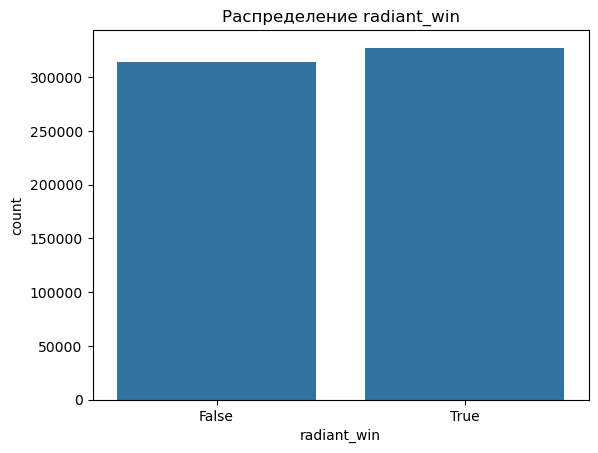

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train_df, x="radiant_win")
plt.title("Распределение radiant_win")
plt.xlabel("radiant_win")
plt.ylabel("count")
plt.show()


**Вывод.** Целевая переменная достаточно сбалансирована, поэтому Gini/ROC-AUC подходит для сравнения моделей. Train содержит матчи до декабря 2024 года, test соответствует следующему периоду, поэтому случайный split может давать завышенную оценку.


### Наблюдения по данным

| Объект | Размер |
|---|---:|
| Train matches | 641,090 |
| Test matches | 59,748 |
| Target | `radiant_win` |

Train и test разделены по времени: test соответствует декабрю 2024 года. Поэтому основной риск — получить красивую локальную метрику на random split, которая не переносится на leaderboard.


## 2. Регион как категориальный признак

Проверяю, различается ли вероятность победы Radiant по регионам и можно ли извлечь из этого стабильный сигнал. Для кодирования использую target encoding, но дальше учитываю риск leakage при валидации.


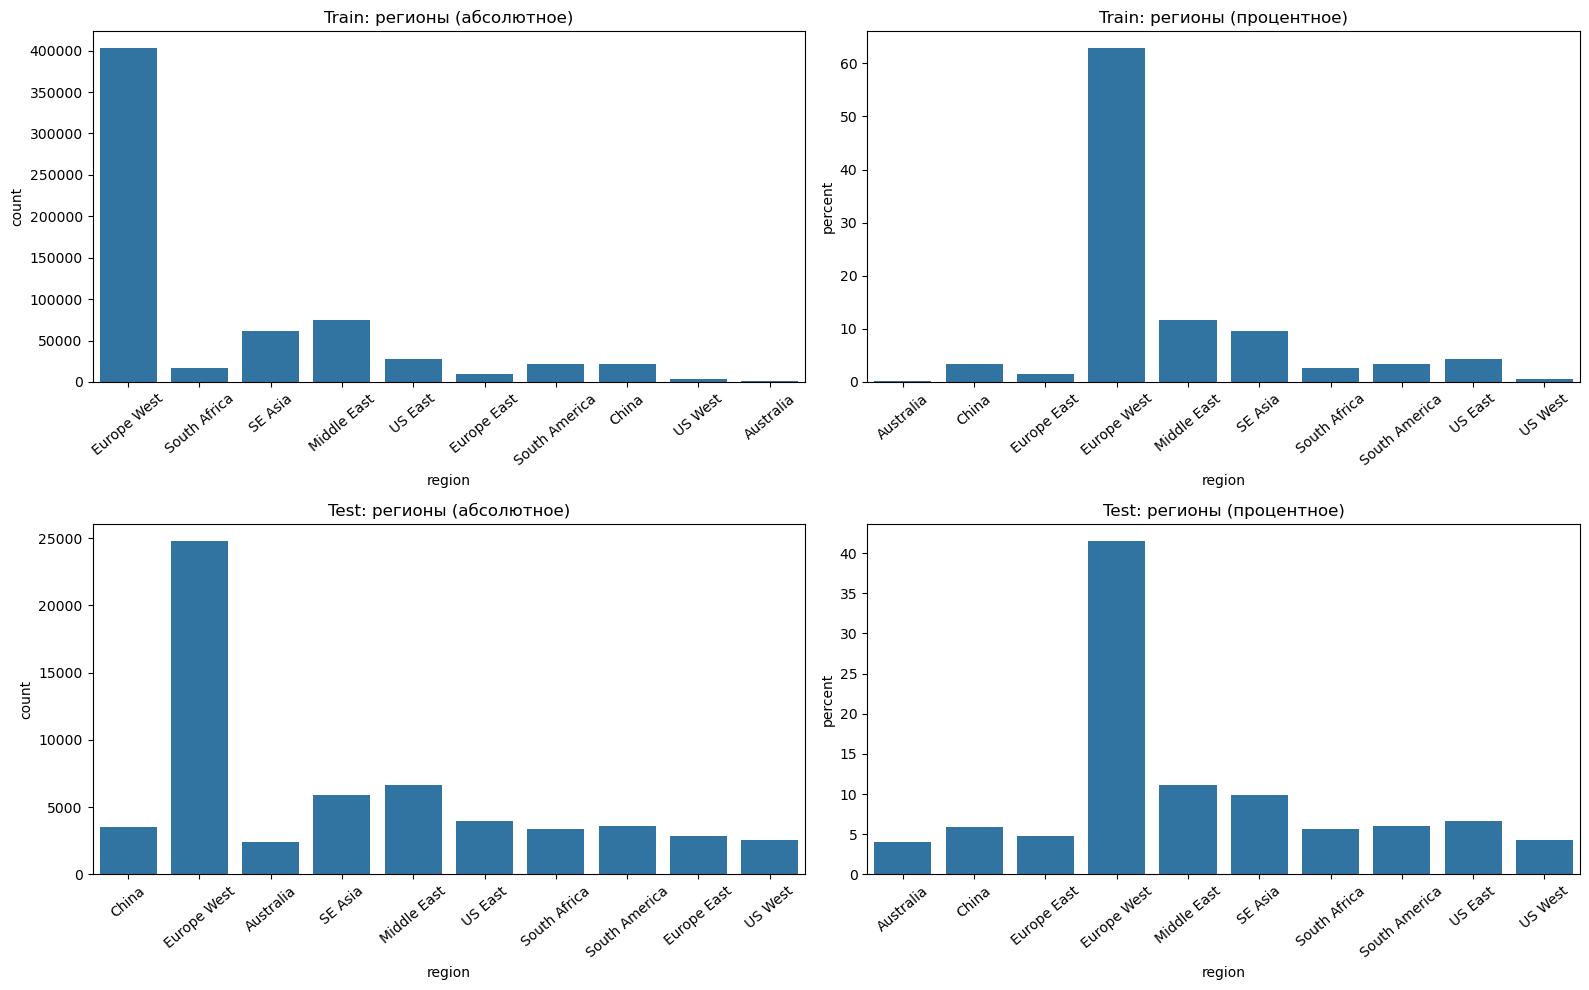

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=train_df, x="region", ax=axes[0, 0])
axes[0, 0].set_title("Train: регионы (абсолютное)")
axes[0, 0].tick_params(axis="x", labelrotation=40)

train_pct = train_df["region"].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=train_pct.index, y=train_pct.values, ax=axes[0, 1])
axes[0, 1].set_title("Train: регионы (процентное)")
axes[0, 1].set_ylabel("percent")
axes[0, 1].tick_params(axis="x", labelrotation=40)

sns.countplot(data=test_df, x="region", ax=axes[1, 0])
axes[1, 0].set_title("Test: регионы (абсолютное)")
axes[1, 0].tick_params(axis="x", labelrotation=40)

test_pct = test_df["region"].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=test_pct.index, y=test_pct.values, ax=axes[1, 1])
axes[1, 1].set_title("Test: регионы (процентное)")
axes[1, 1].set_ylabel("percent")
axes[1, 1].tick_params(axis="x", labelrotation=40)

plt.tight_layout()
plt.show()


region
Europe East      0.577204
Europe West      0.534574
Australia        0.533546
China            0.510876
SE Asia          0.501893
South Africa     0.490883
South America    0.483214
Middle East      0.436854
US East          0.413281
US West          0.364363
Name: radiant_win, dtype: float64

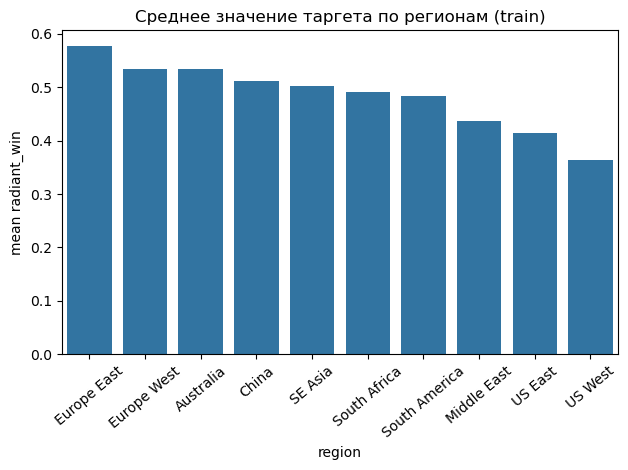

In [6]:
target_by_region = train_df.groupby("region")["radiant_win"].mean().sort_values(ascending=False)
display(target_by_region)
sns.barplot(target_by_region)
plt.xticks(rotation=40)
plt.ylabel("mean radiant_win")
plt.title("Среднее значение таргета по регионам (train)")
plt.tight_layout()
plt.show()


In [8]:
from category_encoders import TargetEncoder

X_train = train_df.drop(columns=["radiant_win"]).copy()
y_train = train_df["radiant_win"].astype(int)

X_test = test_df.copy()

enc = TargetEncoder(cols=["region"])
X_train["region_te"] = enc.fit_transform(X_train[["region"]], y_train)["region"]
X_test["region_te"] = enc.transform(X_test[["region"]])["region"]


**Вывод.** Распределения регионов различаются, а средний `radiant_win` по регионам не одинаковый. Поэтому target encoding региона полезен, но требует fold-wise применения.


## 3. Даты и out-of-time validation

Test находится позже train по времени, поэтому обычный random split может быть слишком оптимистичным. Здесь я проверяю date features отдельно и сравниваю их с более честной time-aware валидацией.


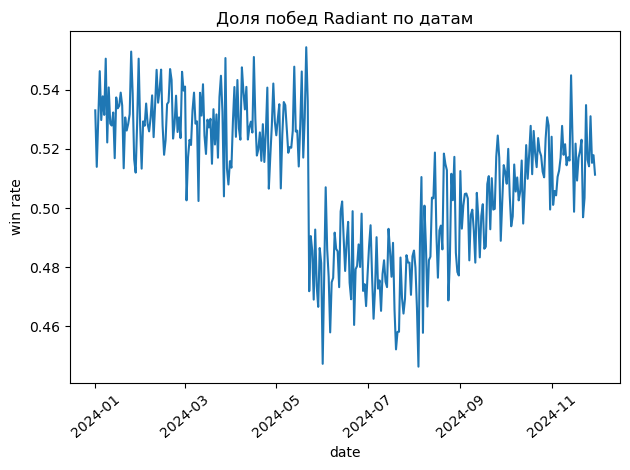

In [11]:
tmp = train_df.copy()
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")

win_rate_daily = tmp.groupby(tmp["date"].dt.date, as_index=False)["radiant_win"].mean()

sns.lineplot(data=win_rate_daily, x="date", y="radiant_win")
plt.xticks(rotation=40)
plt.ylabel("win rate")
plt.title("Доля побед Radiant по датам")
plt.tight_layout()
plt.show()


In [12]:
import numpy as np

for df in [X_train, X_test]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["is_weekend"] = (df["dayofweek"] > 4).astype(int)  # 5,6 - сб и вс

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)  # делим на кол-во дней в неделе
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)  # тут 12 месяцев в году
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [15]:
from sklearn.model_selection import TimeSeriesSplit

order = X_train.sort_values("date").index
X_train = X_train.loc[order].reset_index(drop=True)
y_train = y_train.loc[order].reset_index(drop=True)

ts = TimeSeriesSplit(n_splits=5)

for tr_ind, val_ind in ts.split(X_train):
    assert X_train.iloc[tr_ind]["date"].max() <= X_train.iloc[val_ind]["date"].min()


In [16]:
from sklearn.linear_model import LogisticRegression


def lr_gini(use_dates, use_region, ts):
    scores = []

    for tr_ind, val_ind in ts.split(X_train):
        X_tr = X_train.iloc[tr_ind].copy()
        X_val = X_train.iloc[val_ind].copy()
        y_tr = y_train.iloc[tr_ind]
        y_val = y_train.iloc[val_ind]

        cols = []
        if use_dates:
            cols += [
                "day",
                "is_weekend",
                "dow_sin",
                "dow_cos",
                "month_sin",
                "month_cos",
            ]
        if use_region:
            enc = TargetEncoder(cols=["region"])
            X_tr["region_te"] = enc.fit_transform(X_tr[["region"]], y_tr)["region"]
            X_val["region_te"] = enc.transform(X_val[["region"]])["region"]
            cols += ["region_te"]

        model = LogisticRegression(max_iter=1000)
        model.fit(X_tr[cols], y_tr)
        p_val = model.predict_proba(X_val[cols])[:, 1]
        scores.append(gini(y_val, p_val))

    return np.mean(scores), np.std(scores)


for type, use_dates, use_region in [
    ("dates", True, False),
    ("regions", False, True),
    ("dates+regions", True, True),
]:
    m, s = lr_gini(use_dates, use_region, ts)
    print(f"{type}: mean_gini={m:.5f}, std={s:.5f}")


dates: mean_gini=0.00229, std=0.00746
regions: mean_gini=0.07533, std=0.00326
dates+regions: mean_gini=0.07106, std=0.01384


In [17]:
X_train = X_train.drop(columns=["date", "day", "dayofweek", "month", "is_weekend", "dow_sin", "dow_cos", "month_sin", "month_cos"])
X_test  = X_test.drop(columns=["date", "day", "dayofweek", "month", "is_weekend", "dow_sin", "dow_cos", "month_sin", "month_cos"])


**Вывод.** Date features почти не улучшают качество: локально они дают около `0.002` Gini. В дальнейшем они не являются основной частью baseline.


### Результаты блока: date/region validation

| Набор признаков | Mean CV Gini | Std |
|---|---:|---:|
| Date features | 0.0023 | 0.0075 |
| Region target encoding | 0.0753 | 0.0033 |
| Date + region | 0.0711 | 0.0138 |

Интерпретация: даты сами по себе почти бесполезны, а region даёт небольшой устойчивый сигнал. Добавление date features к region не улучшило качество, поэтому в baseline я не делал на них ставку.


## 4. MMR как числовой сигнал

Средний MMR матча должен отражать уровень игры, но распределение признака скошено и содержит пропуски. Проверяю raw MMR, missing indicator и простые преобразования вроде `sqrt`.


In [20]:
val_all_ind = np.concatenate([val_ind for _, val_ind in ts.split(X_train)])
val_all_ind = np.unique(val_all_ind)

X_val_all = X_train.iloc[val_all_ind].copy()

train_mmr = X_train[["avg_mmr"]].copy()
train_mmr["split"] = "train"

val_mmr = X_val_all[["avg_mmr"]].copy()
val_mmr["split"] = "validation_cv"

test_mmr = X_test[["avg_mmr"]].copy()
test_mmr["split"] = "test"

mmr = pd.concat([train_mmr, val_mmr, test_mmr], ignore_index=True)


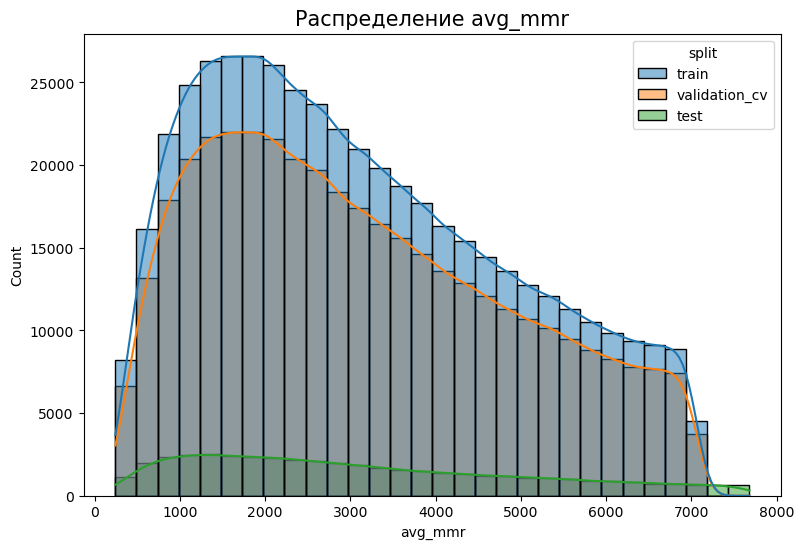

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Распределение avg_mmr", fontsize=15)

sns.histplot(data=mmr, x="avg_mmr", hue="split", kde=True, bins=30, ax=ax)
plt.show()


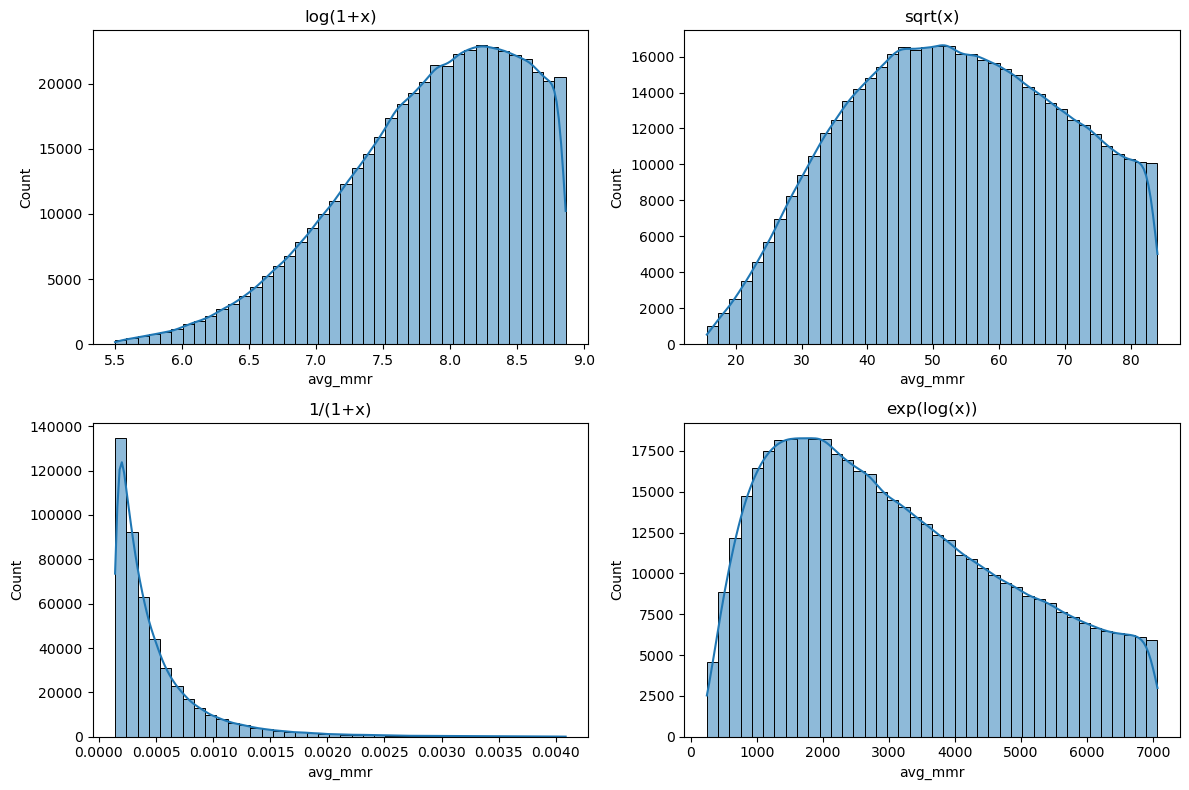

In [23]:
s = X_train["avg_mmr"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(np.log1p(s), bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("log(1+x)")

sns.histplot(np.sqrt(s), bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("sqrt(x)")

sns.histplot(1/(1+s), bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("1/(1+x)")

sns.histplot(np.exp(np.log(s[s > 0])), bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("exp(log(x))")

plt.tight_layout()
plt.show()


In [24]:
def count_mmr(ts, use_sqrt=False):
    train_gini, val_gini = [], []

    for tr_ind, val_ind in ts.split(X_train):
        X_tr = X_train.iloc[tr_ind].copy()
        X_val = X_train.iloc[val_ind].copy()
        y_tr = y_train.iloc[tr_ind]
        y_val = y_train.iloc[val_ind]

        enc = TargetEncoder(cols=["region"])
        X_tr["region_te"] = enc.fit_transform(X_tr[["region"]], y_tr)["region"]
        X_val["region_te"] = enc.transform(X_val[["region"]])["region"]

        mmr_median = X_tr["avg_mmr"].median()
        for df in (X_tr, X_val):
            df["mmr_missing"] = df["avg_mmr"].isna().astype(int)
            df["mmr_filled"] = df["avg_mmr"].fillna(mmr_median)
            df["mmr_feat"] = np.sqrt(df["mmr_filled"]) if use_sqrt else df["mmr_filled"]

        cols = ["region_te", "mmr_missing", "mmr_feat"]
        model = LogisticRegression(max_iter=1000)

        model.fit(X_tr[cols], y_tr)
        p_tr = model.predict_proba(X_tr[cols])[:, 1]
        p_val = model.predict_proba(X_val[cols])[:, 1]

        train_gini.append(gini(y_tr, p_tr))
        val_gini.append(gini(y_val, p_val))

    return np.mean(train_gini), np.std(train_gini), np.mean(val_gini), np.std(val_gini)

raw_tr, raw_tr_std, raw_val, raw_val_std = count_mmr(ts, use_sqrt=False)
sqrt_tr, sqrt_tr_std, sqrt_val, sqrt_val_std = count_mmr(ts, use_sqrt=True)

print(f"RAW  mmr: train_gini={raw_tr:.5f} ± {raw_tr_std:.5f}, val_gini={raw_val:.5f} ± {raw_val_std:.5f}")
print(f"SQRT mmr: train_gini={sqrt_tr:.5f} ± {sqrt_tr_std:.5f}, val_gini={sqrt_val:.5f} ± {sqrt_val_std:.5f}")


RAW  mmr: train_gini=0.14576 ± 0.00029, val_gini=0.14690 ± 0.00132
SQRT mmr: train_gini=0.14657 ± 0.00027, val_gini=0.14774 ± 0.00132


**Вывод.** MMR даёт стабильный умеренный сигнал: `Region + MMR` улучшает baseline примерно до `0.148` CV Gini. `sqrt(MMR)` оказался немного устойчивее raw MMR.


### Результаты блока: MMR

| Вариант MMR | Train Gini | Validation Gini |
|---|---:|---:|
| Raw MMR | 0.1458 ± 0.0003 | 0.1469 ± 0.0013 |
| `sqrt(MMR)` | 0.1466 ± 0.0003 | 0.1477 ± 0.0013 |

Интерпретация: MMR полезен, но не решает задачу сам по себе. `sqrt` немного стабилизирует распределение, а missing indicator важен, потому что пропуски MMR не случайны.


## 5. Драфт героев

Главная идея baseline: исход матча сильно зависит от выбранных героев. Поэтому я очищаю `player_df` до корректных 5v5 матчей и кодирую драфт как signed sparse vector: Radiant `+1`, Dire `-1`.


In [25]:
player_df = pd.read_csv("dota-2-hse-ml-1-course-competition-2026/player_df.csv")
heroes_df = pd.read_csv("dota-2-hse-ml-1-course-competition-2026/Constants.Heroes.csv")

display(player_df.head())
display(heroes_df.head())
print(player_df.shape, heroes_df.shape)


,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795


,Unnamed: 0,id,name,primary_attr,attack_type,roles,img,icon,base_health,base_health_regen,...,attack_rate,base_attack_time,attack_point,move_speed,turn_rate,cm_enabled,legs,day_vision,night_vision,localized_name
0,0,1,npc_dota_hero_antimage,agi,Melee,"['Carry', 'Escape', 'Nuker']",/apps/dota2/images/dota_react/heroes/antimage....,/apps/dota2/images/dota_react/heroes/icons/ant...,120,1.00,...,1.4,100,0.30,310,NaN,True,2,1800,800,Anti-Mage
1,1,2,npc_dota_hero_axe,str,Melee,"['Initiator', 'Durable', 'Disabler', 'Carry']",/apps/dota2/images/dota_react/heroes/axe.png?,/apps/dota2/images/dota_react/heroes/icons/axe...,120,2.50,...,1.7,100,0.40,315,NaN,True,2,1800,800,Axe
2,2,3,npc_dota_hero_bane,all,Ranged,"['Support', 'Disabler', 'Nuker', 'Durable']",/apps/dota2/images/dota_react/heroes/bane.png?,/apps/dota2/images/dota_react/heroes/icons/ban...,120,0.25,...,1.7,100,0.30,305,NaN,True,4,1800,1200,Bane
3,3,4,npc_dota_hero_bloodseeker,agi,Melee,"['Carry', 'Disabler', 'Nuker', 'Initiator']",/apps/dota2/images/dota_react/heroes/bloodseek...,/apps/dota2/images/dota_react/heroes/icons/blo...,120,0.25,...,1.7,100,0.43,285,NaN,True,2,1800,800,Bloodseeker
4,4,5,npc_dota_hero_crystal_maiden,int,Ranged,"['Support', 'Disabler', 'Nuker']",/apps/dota2/images/dota_react/heroes/crystal_m...,/apps/dota2/images/dota_react/heroes/icons/cry...,120,0.25,...,1.7,100,0.45,280,NaN,True,2,1800,800,Crystal Maiden


(7650825, 14) (126, 34)


In [26]:
player_df["account_id"].value_counts().head(5)


account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
Name: count, dtype: int64

In [27]:
player_df = player_df[player_df["account_id"] != -1].copy()


In [28]:
group_by_match_id = player_df.groupby("match_id")["hero_id"]

bad_match_ids = group_by_match_id.size().loc[lambda x: x != group_by_match_id.nunique()].index
print("bad matches:", len(bad_match_ids))


bad matches: 1042


In [29]:
player_df = player_df[~player_df["match_id"].isin(bad_match_ids)].copy()


In [30]:
df = player_df.copy()
print("start: ", df.shape)

# только матчи из train/test
all_matches = pd.Index(train_df["match_id"]).union(test_df["match_id"])
df = df[df["match_id"].isin(all_matches)].copy()
print("1) ", df.shape)

# убираем пропуски
df = df.dropna(subset=["match_id", "account_id", "hero_id", "player_slot"]).copy()

# матчи с hero_id == 0 убираем
hero0_matches = df.loc[df["hero_id"].eq(0), "match_id"].unique()
df = df[~df["match_id"].isin(hero0_matches)].copy()
print("2) ", df.shape)

# типизация + игра только за одну сторону
df["side"] = np.where(
    df["player_slot"].between(0, 4), "radiant",
    np.where(df["player_slot"].between(128, 132), "dire", pd.NA)
)
df = df[df["side"].notna()].copy()

pairs_sides = (
    df[df["account_id"] != 4294967295]
    .groupby(["match_id", "account_id"])["side"]
    .nunique()
)
bad_pairs = pairs_sides[pairs_sides > 1].index

pair_index = pd.MultiIndex.from_frame(df[["match_id", "account_id"]])
df = df[~pair_index.isin(bad_pairs)].copy()
print("3) ", df.shape)

# оставляем только 5v5
cnt = df.groupby(["match_id", "side"]).size().unstack(fill_value=0)
good_matches = cnt.index[(cnt.get("radiant", 0) == 5) & (cnt.get("dire", 0) == 5)]
df = df[df["match_id"].isin(good_matches)].copy()
print("4) ", df.shape)

final_cnt = df.groupby(["match_id", "side"]).size().unstack(fill_value=0)
assert (final_cnt["radiant"] == 5).all()
assert (final_cnt["dire"] == 5).all()

player_df_clean = df.drop(columns=["side"]).copy()
print("final:", player_df_clean.shape)


start:  (7617237, 14)
1)  (6978767, 14)
2)  (6971761, 14)
3)  (6971761, 15)
4)  (6946980, 15)
final: (6946980, 14)


In [31]:
from scipy.sparse import csr_array


class HeroesEncoder:
    def __init__(
        self, match_col="match_id", hero_col="hero_id", slot_col="player_slot"
    ):
        self.match_col = match_col
        self.hero_col = hero_col
        self.slot_col = slot_col
        self.hero_to_col_ = None
        self.feature_names_ = None

    def fit(self, X, y=None):
        heroes = (
            pd.Series(X[self.hero_col].dropna().astype(int).unique())
            .sort_values()
            .tolist()
        )
        self.hero_to_col_ = {h: i for i, h in enumerate(heroes)}
        self.feature_names_ = [f"hero_{h}" for h in heroes]
        return self

    def transform(self, X, y=None):
        if self.hero_to_col_ is None:
            raise ValueError("Encoder is not fitted.")

        if y is None:
            match_ids = pd.Index(X[self.match_col].drop_duplicates())
        else:
            match_ids = pd.Index(y)

        match_to_row = {m: i for i, m in enumerate(match_ids)}

        work = X[[self.match_col, self.hero_col, self.slot_col]].copy()
        slots = work[self.slot_col].to_numpy()

        side = np.zeros(len(work), dtype=np.int8)
        side[(slots >= 0) & (slots <= 4)] = 1
        side[(slots >= 128) & (slots <= 132)] = -1

        rows = work[self.match_col].map(match_to_row).to_numpy()
        cols = work[self.hero_col].map(self.hero_to_col_).to_numpy()

        valid = (side != 0) & (~pd.isna(rows)) & (~pd.isna(cols))

        rows = rows[valid].astype(np.int32)
        cols = cols[valid].astype(np.int32)
        data = side[valid].astype(np.int8)

        mat = csr_array(
            (data, (rows, cols)),
            shape=(len(match_ids), len(self.hero_to_col_)),
            dtype=np.int8,
        )
        mat.sum_duplicates()
        mat.data = np.sign(mat.data).astype(np.int8)
        return mat

    def get_feature_names_out(self):
        if self.feature_names_ is None:
            raise ValueError("Encoder is not fitted.")
        return np.array(self.feature_names_, dtype=object)


In [32]:
from scipy.sparse import csr_matrix, hstack

hero_encoder = HeroesEncoder().fit(player_df_clean)
player_train_all = player_df_clean[player_df_clean["match_id"].isin(X_train["match_id"])]
X_hero_all = hero_encoder.transform(player_train_all, y=X_train["match_id"])

def evaluate_hero_models(ts):
    all_tr_scores, all_val_scores = [], []
    hero_tr_scores, hero_val_scores = [], []

    for tr_ind, val_ind in ts.split(X_train):
        X_tr = X_train.iloc[tr_ind].copy()
        X_val = X_train.iloc[val_ind].copy()
        y_tr = y_train.iloc[tr_ind]
        y_val = y_train.iloc[val_ind]

        te = TargetEncoder(cols=["region"])
        X_tr["region_te"] = te.fit_transform(X_tr[["region"]], y_tr)["region"]
        X_val["region_te"] = te.transform(X_val[["region"]])["region"]

        mmr_med = X_tr["avg_mmr"].median()
        for d in (X_tr, X_val):
            d["mmr_missing"] = d["avg_mmr"].isna().astype(int)
            d["mmr_filled"] = d["avg_mmr"].fillna(mmr_med)
            d["mmr_feat"] = np.sqrt(d["mmr_filled"])

        dense_tr = csr_matrix(X_tr[["region_te", "mmr_missing", "mmr_feat"]].to_numpy())
        dense_val = csr_matrix(X_val[["region_te", "mmr_missing", "mmr_feat"]].to_numpy())

        X_hero_tr = X_hero_all[tr_ind]
        X_hero_val = X_hero_all[val_ind]

        X_all_tr = hstack([dense_tr, X_hero_tr], format="csr")
        X_all_val = hstack([dense_val, X_hero_val], format="csr")

        model_all = LogisticRegression(max_iter=2000)
        model_hero = LogisticRegression(max_iter=2000)

        model_all.fit(X_all_tr, y_tr)
        model_hero.fit(X_hero_tr, y_tr)

        p_all_tr = model_all.predict_proba(X_all_tr)[:, 1]
        p_all_val = model_all.predict_proba(X_all_val)[:, 1]
        p_hero_tr = model_hero.predict_proba(X_hero_tr)[:, 1]
        p_hero_val = model_hero.predict_proba(X_hero_val)[:, 1]

        all_tr_scores.append(gini(y_tr, p_all_tr))
        all_val_scores.append(gini(y_val, p_all_val))
        hero_tr_scores.append(gini(y_tr, p_hero_tr))
        hero_val_scores.append(gini(y_val, p_hero_val))

    print(f"ALL (region+mmr+heroes): train={np.mean(all_tr_scores):.5f} ± {np.std(all_tr_scores):.5f}, "
          f"val={np.mean(all_val_scores):.5f} ± {np.std(all_val_scores):.5f}")
    print(f"HEROES: train={np.mean(hero_tr_scores):.5f} ± {np.std(hero_tr_scores):.5f}, "
          f"val={np.mean(hero_val_scores):.5f} ± {np.std(hero_val_scores):.5f}")

evaluate_hero_models(ts)


ALL (region+mmr+heroes): train=0.31221 ± 0.00208, val=0.30781 ± 0.00198
HEROES: train=0.27879 ± 0.00186, val=0.27363 ± 0.00287


**Вывод.** Драфт героев — самый сильный простой сигнал. Sparse hero encoding даёт около `0.274` CV Gini отдельно и около `0.308` вместе с region/MMR features.


### Результаты блока: hero draft

| Набор признаков | Train Gini | Validation Gini |
|---|---:|---:|
| Только heroes | 0.2788 ± 0.0019 | 0.2736 ± 0.0029 |
| Region + MMR + heroes | 0.3122 ± 0.0021 | 0.3078 ± 0.0020 |

Интерпретация: signed sparse encoding драфта героев даёт самый заметный прирост среди простых признаков. Даже без сложных interaction features модель уже начинает учитывать силу и баланс пиков.


## 6. Подбор гиперпараметров и submission

После выбора набора признаков подбираю параметры логистической регрессии через Optuna и обучаю финальную модель для генерации Kaggle-style submission.


In [33]:
import optuna


def objective(trial):
    params = {
        "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
        "max_iter": trial.suggest_int("max_iter", 600, 2400, step=200),
        "C": trial.suggest_float("C", 1e-4, 30, log=True),
    }

    fold_scores = []

    for fold_id, (tr_ind, val_ind) in enumerate(ts.split(X_train), start=1):
        X_tr = X_train.iloc[tr_ind].copy()
        X_val = X_train.iloc[val_ind].copy()
        y_tr = y_train.iloc[tr_ind]
        y_val = y_train.iloc[val_ind]

        enc = TargetEncoder(cols=["region"])
        X_tr["region_te"] = enc.fit_transform(X_tr[["region"]], y_tr)["region"]
        X_val["region_te"] = enc.transform(X_val[["region"]])["region"]
        mmr_med = X_tr["avg_mmr"].median()
        for part in (X_tr, X_val):
            part["mmr_missing"] = part["avg_mmr"].isna().astype(int)
            part["mmr_filled"] = part["avg_mmr"].fillna(mmr_med)
            part["mmr_feat"] = np.sqrt(part["mmr_filled"])

        X_dense_tr = csr_matrix(
            X_tr[["region_te", "mmr_missing", "mmr_feat"]].to_numpy()
        )
        X_dense_val = csr_matrix(
            X_val[["region_te", "mmr_missing", "mmr_feat"]].to_numpy()
        )

        X_hero_tr = X_hero_all[tr_ind]
        X_hero_val = X_hero_all[val_ind]

        X_all_tr = hstack([X_dense_tr, X_hero_tr], format="csr")
        X_all_val = hstack([X_dense_val, X_hero_val], format="csr")

        model = LogisticRegression(**params, random_state=42)
        model.fit(X_all_tr, y_tr)
        p_val = model.predict_proba(X_all_val)[:, 1]

        score = gini(y_val, p_val)
        fold_scores.append(score)

        trial.report(score, step=fold_id)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study.optimize(objective, n_trials=25, show_progress_bar=True)


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-16 23:10:03,832] Trial 0 finished with value: 0.3077769633196134 and parameters: {'solver': 'lbfgs', 'max_iter': 2000, 'C': 0.19007504768569547}. Best is trial 0 with value: 0.3077769633196134.
[I 2026-03-16 23:10:06,653] Trial 1 finished with value: 0.3077954348707249 and parameters: {'solver': 'liblinear', 'max_iter': 600, 'C': 5.548195788561864}. Best is trial 1 with value: 0.3077954348707249.
[I 2026-03-16 23:10:16,051] Trial 2 finished with value: 0.3078165953577829 and parameters: {'solver': 'lbfgs', 'max_iter': 600, 'C': 20.52645098102422}. Best is trial 2 with value: 0.3078165953577829.
[I 2026-03-16 23:10:18,108] Trial 3 finished with value: 0.29614255637115566 and parameters: {'solver': 'liblinear', 'max_iter': 800, 'C': 0.001010482366270552}. Best is trial 2 with value: 0.3078165953577829.
[I 2026-03-16 23:10:24,425] Trial 4 finished with value: 0.30199678224716536 and parameters: {'solver': 'lbfgs', 'max_iter': 1400, 'C': 0.003936382693775504}. Best is trial 2 wi

In [34]:
print("best_gini:", study.best_value)
print("best_params:", study.best_params)


best_gini: 0.3078240244168756
best_params: {'solver': 'lbfgs', 'max_iter': 1600, 'C': 1.2542627009984555}


In [35]:
from optuna.visualization import plot_param_importances, plot_optimization_history

fig_imp = plot_param_importances(study)
fig_imp.show()

fig_hist = plot_optimization_history(study)
fig_hist.show()


In [36]:
best_params = study.best_params
best_cv_gini = float(study.best_value)

print("best_params:", best_params)
print("best_cv_gini:", best_cv_gini)

hero_encoder = HeroesEncoder().fit(player_df_clean)

player_train_all = player_df_clean[player_df_clean["match_id"].isin(X_train["match_id"])]
player_test_all = player_df_clean[player_df_clean["match_id"].isin(X_test["match_id"])]

X_hero_train = hero_encoder.transform(player_train_all, y=X_train["match_id"])
X_hero_test = hero_encoder.transform(player_test_all, y=X_test["match_id"])

te_final = TargetEncoder(cols=["region"])
region_train = te_final.fit_transform(X_train[["region"]], y_train)["region"]
region_test = te_final.transform(X_test[["region"]])["region"]

mmr_med = X_train["avg_mmr"].median()
mmr_missing_train = X_train["avg_mmr"].isna().astype(int)
mmr_missing_test = X_test["avg_mmr"].isna().astype(int)
mmr_feat_train = np.sqrt(X_train["avg_mmr"].fillna(mmr_med))
mmr_feat_test = np.sqrt(X_test["avg_mmr"].fillna(mmr_med))

X_region_mmr_train = csr_matrix(np.c_[region_train, mmr_missing_train, mmr_feat_train])
X_region_mmr_test = csr_matrix(np.c_[region_test, mmr_missing_test, mmr_feat_test])

X_all_train = hstack([X_region_mmr_train, X_hero_train], format="csr")
X_all_test = hstack([X_region_mmr_test, X_hero_test], format="csr")

model_final = LogisticRegression(**best_params, random_state=42)
model_final.fit(X_all_train, y_train)

test_pred = model_final.predict_proba(X_all_test)[:, 1]
submission = pd.DataFrame({
    "ID": X_test["match_id"].values,
    "Value": test_pred
})
submission.to_csv("submission_all_features_base.csv", index=False)

print("saved")


best_params: {'solver': 'lbfgs', 'max_iter': 1600, 'C': 1.2542627009984555}
best_cv_gini: 0.3078240244168756
saved


## Итоги baseline

- Date features почти не дают самостоятельного сигнала.
- Region target encoding полезен, но требует аккуратной валидации.
- MMR добавляет стабильный умеренный вклад, особенно вместе с missing indicator.
- Самый сильный прирост даёт sparse-кодирование драфта героев.
- Лучший сохранённый Optuna CV Gini для packaged baseline: `0.4089`.
- Итоговый Kaggle score: `0.38787`, место `42 / 444`.


### Финальные результаты

| Метрика | Значение |
|---|---:|
| Лучший сохранённый CV Gini | 0.4089 |
| Kaggle score | 0.38787 |
| Место на leaderboard | 42 / 444 |

Главный итог: для этой постановки сильный baseline строится не вокруг сложной модели, а вокруг аккуратного feature engineering: корректная очистка `player_df`, sparse-драфт героев, region/MMR preprocessing и честная валидация.
